In [54]:
from pathlib import Path
import os
import numpy as np

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"

RAW_VIDEO_DIR = PROJECT_ROOT / "dataset" / "raw_videos"
HYBRID_KEYPOINT_DIR = PROJECT_ROOT / "dataset" / "processed_keypoints_hybrid"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)

print("Current directory:", Path.cwd())
print("Raw video folder exists:", RAW_VIDEO_DIR.exists())
print("Keypoint folder exists:", HYBRID_KEYPOINT_DIR.exists())
print("Model folder:", MODEL_DIR)

Current directory: /Users/venubandi/Desktop/Gesture_Project
Raw video folder exists: True
Keypoint folder exists: True
Model folder: /Users/venubandi/Desktop/Gesture_Project/models


In [55]:
actions = sorted([p.name for p in RAW_VIDEO_DIR.iterdir() if p.is_dir()])

print("Raw video counts:")
for action in actions:
    action_dir = RAW_VIDEO_DIR / action
    videos = list(action_dir.glob("*.mov")) + list(action_dir.glob("*.mp4"))
    print(f"{action:15s}: {len(videos)}")

print("\nExisting keypoint counts:")
total_keypoints = 0

for action in actions:
    kp_dir = HYBRID_KEYPOINT_DIR / action
    count = len(list(kp_dir.glob("*.npy"))) if kp_dir.exists() else 0
    total_keypoints += count
    print(f"{action:15s}: {count}")

print("\nTotal existing keypoint files:", total_keypoints)

Raw video counts:
abort          : 80
danger         : 80
help           : 80
need_backup    : 80
no_gesture     : 80
proceed        : 80
safe           : 80
stay           : 80
watched        : 80

Existing keypoint counts:
abort          : 80
danger         : 80
help           : 80
need_backup    : 80
no_gesture     : 80
proceed        : 80
safe           : 80
stay           : 80
watched        : 80

Total existing keypoint files: 720


In [56]:
import cv2
import mediapipe as mp
from tqdm import tqdm

mp_holistic = mp.solutions.holistic

POSE_LANDMARKS = 33
FACE_LANDMARKS = 478
HAND_LANDMARKS = 21

POSE_SIZE = POSE_LANDMARKS * 4
FACE_SIZE = FACE_LANDMARKS * 3
HAND_SIZE = HAND_LANDMARKS * 3

TOTAL_FEATURES = POSE_SIZE + FACE_SIZE + HAND_SIZE + HAND_SIZE
SEQUENCE_LENGTH = 30

expected_total = sum(
    len(list((RAW_VIDEO_DIR / action).glob("*.mov"))) + len(list((RAW_VIDEO_DIR / action).glob("*.mp4")))
    for action in actions
)

existing_total = sum(
    len(list((HYBRID_KEYPOINT_DIR / action).glob("*.npy"))) if (HYBRID_KEYPOINT_DIR / action).exists() else 0
    for action in actions
)

print("Expected keypoint files:", expected_total)
print("Existing keypoint files:", existing_total)

def extract_landmarks(results):
    if results.pose_landmarks:
        pose = np.array([
            [lm.x, lm.y, lm.z, lm.visibility]
            for lm in results.pose_landmarks.landmark
        ]).flatten()
    else:
        pose = np.zeros(POSE_SIZE)

    if results.face_landmarks:
        face = np.array([
            [lm.x, lm.y, lm.z]
            for lm in results.face_landmarks.landmark
        ]).flatten()

        if len(face) < FACE_SIZE:
            face = np.pad(face, (0, FACE_SIZE - len(face)))
        elif len(face) > FACE_SIZE:
            face = face[:FACE_SIZE]
    else:
        face = np.zeros(FACE_SIZE)

    if results.left_hand_landmarks:
        left_hand = np.array([
            [lm.x, lm.y, lm.z]
            for lm in results.left_hand_landmarks.landmark
        ]).flatten()
    else:
        left_hand = np.zeros(HAND_SIZE)

    if results.right_hand_landmarks:
        right_hand = np.array([
            [lm.x, lm.y, lm.z]
            for lm in results.right_hand_landmarks.landmark
        ]).flatten()
    else:
        right_hand = np.zeros(HAND_SIZE)

    keypoints = np.concatenate([pose, face, left_hand, right_hand])

    if len(keypoints) < TOTAL_FEATURES:
        keypoints = np.pad(keypoints, (0, TOTAL_FEATURES - len(keypoints)))
    elif len(keypoints) > TOTAL_FEATURES:
        keypoints = keypoints[:TOTAL_FEATURES]

    return keypoints.astype(np.float32)


def sample_or_pad_sequence(sequence, target_len=30):
    if len(sequence) == 0:
        return np.zeros((target_len, TOTAL_FEATURES), dtype=np.float32)

    sequence = np.vstack(sequence).astype(np.float32)

    if len(sequence) >= target_len:
        indices = np.linspace(0, len(sequence) - 1, target_len).astype(int)
        return sequence[indices]

    padding = np.zeros((target_len - len(sequence), TOTAL_FEATURES), dtype=np.float32)
    return np.vstack([sequence, padding])


def extract_keypoints_from_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    sequence = []

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        enable_segmentation=False,
        refine_face_landmarks=True,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image_rgb.flags.writeable = False

            results = holistic.process(image_rgb)
            keypoints = extract_landmarks(results)
            sequence.append(keypoints)

    cap.release()
    return sample_or_pad_sequence(sequence, SEQUENCE_LENGTH)


if existing_total == expected_total and existing_total > 0:
    print("✅ Keypoints already exist and are complete. Skipping extraction.")
else:
    print("⚠️ Keypoints incomplete. Running extraction only for missing files...")

    failed_videos = []
    processed_count = 0
    skipped_count = 0

    for action in actions:
        input_action_dir = RAW_VIDEO_DIR / action
        output_action_dir = HYBRID_KEYPOINT_DIR / action
        output_action_dir.mkdir(parents=True, exist_ok=True)

        videos = sorted(list(input_action_dir.glob("*.mov")) + list(input_action_dir.glob("*.mp4")))

        print(f"\nProcessing action: {action} | Videos: {len(videos)}")

        for video_path in tqdm(videos):
            output_path = output_action_dir / f"{video_path.stem}.npy"

            if output_path.exists():
                skipped_count += 1
                continue

            try:
                keypoints = extract_keypoints_from_video(video_path)

                if keypoints.shape != (SEQUENCE_LENGTH, TOTAL_FEATURES):
                    failed_videos.append((str(video_path), f"Wrong shape: {keypoints.shape}"))
                    continue

                if np.isnan(keypoints).any():
                    failed_videos.append((str(video_path), "Contains NaN"))
                    continue

                np.save(output_path, keypoints)
                processed_count += 1

            except Exception as e:
                failed_videos.append((str(video_path), str(e)))

    print("\nExtraction complete.")
    print("New files processed:", processed_count)
    print("Skipped existing files:", skipped_count)
    print("Failed videos:", len(failed_videos))

    if failed_videos:
        print("\nFailed video examples:")
        for item in failed_videos[:10]:
            print(item)

Expected keypoint files: 720
Existing keypoint files: 720
✅ Keypoints already exist and are complete. Skipping extraction.


In [57]:
bad_files = []
total_files = 0

for action in actions:
    action_dir = HYBRID_KEYPOINT_DIR / action
    npy_files = sorted(action_dir.glob("*.npy"))
    total_files += len(npy_files)

    print(f"{action:15s}: {len(npy_files)} files")

    for f in npy_files:
        arr = np.load(f)

        if arr.shape != (30, 1692):
            bad_files.append((str(f), f"Wrong shape {arr.shape}"))

        if np.isnan(arr).any():
            bad_files.append((str(f), "Contains NaN"))

        if np.isinf(arr).any():
            bad_files.append((str(f), "Contains Inf"))

print("\nTotal files:", total_files)
print("Bad files:", len(bad_files))

if bad_files:
    print("\nBad file examples:")
    for item in bad_files[:20]:
        print(item)
else:
    print("\n✅ All keypoint files are valid.")

abort          : 80 files
danger         : 80 files
help           : 80 files
need_backup    : 80 files
no_gesture     : 80 files
proceed        : 80 files
safe           : 80 files
stay           : 80 files
watched        : 80 files

Total files: 720
Bad files: 0

✅ All keypoint files are valid.


In [58]:
# ---------------------------------------
# CELL 5: Load Keypoint Dataset
# ---------------------------------------

X = []
y = []

for action in actions:
    action_dir = HYBRID_KEYPOINT_DIR / action
    npy_files = sorted(action_dir.glob("*.npy"))

    for file in npy_files:
        arr = np.load(file)
        X.append(arr)
        y.append(action)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(set(y)))

X shape: (720, 30, 1692)
y shape: (720,)
Classes: ['abort', 'danger', 'help', 'need_backup', 'no_gesture', 'proceed', 'safe', 'stay', 'watched']


In [64]:
# ---------------------------------------
# CELL 6: Encode Labels and Split Dataset
# ---------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import json

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = list(label_encoder.classes_)

print("Class names:")
for i, name in enumerate(class_names):
    print(i, "→", name)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

class_names_path = MODEL_DIR / "class_names.json"

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

print("\nSaved class names to:", class_names_path)

Class names:
0 → abort
1 → danger
2 → help
3 → need_backup
4 → no_gesture
5 → proceed
6 → safe
7 → stay
8 → watched

Dataset split:
Train: (504, 30, 1692) (504,)
Val:   (108, 30, 1692) (108,)
Test:  (108, 30, 1692) (108,)

Saved class names to: /Users/venubandi/Desktop/Gesture_Project/models/class_names.json


In [65]:
# ---------------------------------------
# CELL 7: Selected Features + Motion Deltas
# ---------------------------------------

POSE_OFFSET = 0
FACE_OFFSET = 132
LEFT_HAND_OFFSET = 132 + (478 * 3)
RIGHT_HAND_OFFSET = LEFT_HAND_OFFSET + (21 * 3)

SELECTED_POSE = [
    0, 2, 5, 7, 8,      # nose, eyes/ears
    11, 12,             # shoulders
    13, 14,             # elbows
    15, 16              # wrists
]

SELECTED_FACE = [
    # eyes
    33, 133, 159, 145, 160, 144, 158, 153,
    362, 263, 386, 374, 385, 380, 387, 373,

    # iris / refined eye landmarks
    468, 469, 470, 471, 472, 473, 474, 475, 476, 477,

    # mouth
    61, 291, 13, 14, 17, 0, 78, 308, 82, 312,

    # nose
    1, 2, 98, 327, 168,

    # forehead / eyebrow / face reference
    10, 151, 70, 63, 105, 336, 296, 334,

    # cheek / side-face reference
    234, 454
]

def select_features_from_sequence(seq):
    selected_parts = []

    # Pose selected landmarks: x, y, z, visibility
    for idx in SELECTED_POSE:
        start = POSE_OFFSET + idx * 4
        selected_parts.append(seq[:, start:start+4])

    # Face selected landmarks: x, y, z
    for idx in SELECTED_FACE:
        start = FACE_OFFSET + idx * 3
        selected_parts.append(seq[:, start:start+3])

    # Full left hand
    selected_parts.append(seq[:, LEFT_HAND_OFFSET:LEFT_HAND_OFFSET + 63])

    # Full right hand
    selected_parts.append(seq[:, RIGHT_HAND_OFFSET:RIGHT_HAND_OFFSET + 63])

    selected = np.concatenate(selected_parts, axis=1)

    # Add motion deltas
    deltas = np.diff(selected, axis=0, prepend=selected[0:1])

    combined = np.concatenate([selected, deltas], axis=1)

    return combined.astype(np.float32)

def transform_dataset_selected(X_data):
    return np.array([select_features_from_sequence(seq) for seq in X_data], dtype=np.float32)

X_train_sel = transform_dataset_selected(X_train)
X_val_sel = transform_dataset_selected(X_val)
X_test_sel = transform_dataset_selected(X_test)

print("Original train shape:", X_train.shape)
print("Selected train shape:", X_train_sel.shape)
print("Selected val shape  :", X_val_sel.shape)
print("Selected test shape :", X_test_sel.shape)

Original train shape: (504, 30, 1692)
Selected train shape: (504, 30, 646)
Selected val shape  : (108, 30, 646)
Selected test shape : (108, 30, 646)


In [66]:
# ---------------------------------------
# CELL 8: Normalize Features and Create DataLoaders
# ---------------------------------------

import torch
from torch.utils.data import TensorDataset, DataLoader

sel_mean = X_train_sel.mean(axis=(0, 1), keepdims=True)
sel_std = X_train_sel.std(axis=(0, 1), keepdims=True)

sel_std[sel_std < 1e-6] = 1.0

X_train_sel_norm = (X_train_sel - sel_mean) / sel_std
X_val_sel_norm = (X_val_sel - sel_mean) / sel_std
X_test_sel_norm = (X_test_sel - sel_mean) / sel_std

print("Normalized train mean:", X_train_sel_norm.mean())
print("Normalized train std :", X_train_sel_norm.std())

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

BATCH_SIZE = 16

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train_sel_norm, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val_sel_norm, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test_sel_norm, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))
print("Input size   :", X_train_sel_norm.shape[2])
print("Classes      :", len(class_names))

Normalized train mean: -2.6198353e-07
Normalized train std : 0.99690413
Using device: mps
Train batches: 32
Val batches  : 7
Test batches : 7
Input size   : 646
Classes      : 9


In [67]:
# ---------------------------------------
# CELL 9: Weighted Motion BiLSTM Model
# ---------------------------------------

import torch.nn as nn

class MotionBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.30):
        super(MotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        return self.classifier(pooled)

model = MotionBiLSTM(
    input_size=X_train_sel_norm.shape[2],
    hidden_size=160,
    num_layers=2,
    num_classes=len(class_names),
    dropout=0.30
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

MotionBiLSTM(
  (lstm): LSTM(646, 160, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=320, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=9, bias=True)
  )
)
Total parameters: 1701129


In [71]:
# ---------------------------------------
# CELL 10: Train With Focal Loss + Weak-Class Boost
# ---------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
from tqdm import tqdm
import numpy as np
import random
import time

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction="none")

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# Weak classes from your test report
weak_classes = ["safe", "stay", "proceed", "no_gesture"]

# Base class weights = 1
manual_weights = np.ones(len(class_names), dtype=np.float32)

# Boost weak classes
for cls in weak_classes:
    idx = class_names.index(cls)
    manual_weights[idx] = 2.2

print("Class weights:")
for i, cls in enumerate(class_names):
    print(f"{cls:15s}: {manual_weights[i]}")

class_weights_tensor = torch.tensor(manual_weights, dtype=torch.float32).to(device)

SEEDS = [7, 21, 42, 77, 123]
EPOCHS = 150
PATIENCE = 30

overall_best_val_acc = 0.0
overall_best_model_state = None
overall_best_seed = None
overall_best_history = None

all_seed_results = []

start_all = time.time()

for seed in SEEDS:
    print("\n" + "=" * 70)
    print(f"Training with seed: {seed}")
    print("=" * 70)

    set_seed(seed)

    model = MotionBiLSTM(
        input_size=X_train_sel_norm.shape[2],
        hidden_size=192,
        num_layers=2,
        num_classes=len(class_names),
        dropout=0.35
    ).to(device)

    criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.0005,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=8
    )

    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(EPOCHS):
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in tqdm(train_loader, desc=f"Seed {seed} Epoch {epoch+1}", leave=False):
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

            _, preds = torch.max(outputs, 1)
            train_correct += (preds == batch_y).sum().item()
            train_total += batch_y.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item() * batch_X.size(0)

                _, preds = torch.max(outputs, 1)
                val_correct += (preds == batch_y).sum().item()
                val_total += batch_y.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        scheduler.step(val_acc)

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
            best_status = "✅ New seed-best"
        else:
            patience_counter += 1
            best_status = ""

        print(
            f"Seed {seed} | Epoch {epoch+1:03d}/{EPOCHS} | "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f} {best_status}"
        )

        if patience_counter >= PATIENCE:
            print(f"Early stopping for seed {seed} at epoch {epoch+1}")
            break

    all_seed_results.append({
        "seed": seed,
        "best_val_acc": best_val_acc
    })

    print(f"\nSeed {seed} best validation accuracy: {best_val_acc:.4f}")

    if best_val_acc > overall_best_val_acc:
        overall_best_val_acc = best_val_acc
        overall_best_model_state = deepcopy(best_model_state)
        overall_best_seed = seed
        overall_best_history = history

print("\n" + "=" * 70)
print("FOCAL LOSS MULTI-SEED TRAINING COMPLETE")
print("=" * 70)

print("All seed results:")
for result in all_seed_results:
    print(result)

print("\nOverall best seed:", overall_best_seed)
print("Overall best validation accuracy:", round(overall_best_val_acc, 4))
print("Total time:", round(time.time() - start_all, 2), "seconds")

model.load_state_dict(overall_best_model_state)
history = overall_best_history

print("Best focal-loss model loaded into memory.")

Class weights:
abort          : 1.0
danger         : 1.0
help           : 1.0
need_backup    : 1.0
no_gesture     : 2.200000047683716
proceed        : 2.200000047683716
safe           : 2.200000047683716
stay           : 2.200000047683716
watched        : 1.0

Training with seed: 7



Seed 7 Epoch 1: 100%|███████████████████████████| 32/32 [00:00<00:00, 31.38it/s]
                                                                                

Seed 7 | Epoch 001/150 | Train Acc: 0.1766 | Val Acc: 0.2130 | LR: 0.000500 ✅ New seed-best



Seed 7 Epoch 2:  97%|██████████████████████████▏| 31/32 [00:00<00:00, 70.04it/s]
                                                                                

Seed 7 | Epoch 002/150 | Train Acc: 0.2500 | Val Acc: 0.3889 | LR: 0.000500 ✅ New seed-best


...

Seed 123 | Epoch 080/150 | Train Acc: 0.9444 | Val Acc: 0.7130 | LR: 0.000016 



Seed 123 Epoch 81:  97%|███████████████████████▎| 31/32 [00:00<00:00, 70.40it/s]
                                                                                

Seed 123 | Epoch 081/150 | Train Acc: 0.9504 | Val Acc: 0.7130 | LR: 0.000016 



Seed 123 Epoch 82:  97%|███████████████████████▎| 31/32 [00:00<00:00, 70.27it/s]
                                                                                

Seed 123 | Epoch 082/150 | Train Acc: 0.9484 | Val Acc: 0.7130 | LR: 0.000016 
Early stopping for seed 123 at epoch 82

Seed 123 best validation accuracy: 0.7500

FOCAL LOSS MULTI-SEED TRAINING COMPLETE
All seed results:
{'seed': 7, 'best_val_acc': 0.7685185185185185}
{'seed': 21, 'best_val_acc': 0.7222222222222222}
{'seed': 42, 'best_val_acc': 0.7685185185185185}
{'seed': 77, 'best_val_acc': 0.7592592592592593}
{'seed': 123, 'best_val_acc': 0.75}

Overall best seed: 7
Overall best validation accuracy: 0.7685
Total time: 204.34 seconds
Best focal-loss model loaded into memory.


In [73]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
import torch

model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

test_acc = accuracy_score(test_labels, test_preds)

print("Test Accuracy:", round(test_acc, 4))

print("\nTest Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

test_cm = confusion_matrix(test_labels, test_preds)

test_cm_df = pd.DataFrame(
    test_cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

test_cm_df

Test Accuracy: 0.6481

Test Classification Report:
              precision    recall  f1-score   support

       abort       0.71      0.83      0.77        12
      danger       0.79      0.92      0.85        12
        help       0.90      0.75      0.82        12
 need_backup       0.69      0.75      0.72        12
  no_gesture       0.44      0.67      0.53        12
     proceed       0.71      0.42      0.53        12
        safe       0.42      0.42      0.42        12
        stay       0.67      0.33      0.44        12
     watched       0.64      0.75      0.69        12

    accuracy                           0.65       108
   macro avg       0.66      0.65      0.64       108
weighted avg       0.66      0.65      0.64       108



,Pred_abort,Pred_danger,Pred_help,Pred_need_backup,Pred_no_gesture,Pred_proceed,Pred_safe,Pred_stay,Pred_watched
True_abort,10,0,0,1,0,0,0,0,1
True_danger,0,11,1,0,0,0,0,0,0
True_help,1,1,9,1,0,0,0,0,0
True_need_backup,0,1,0,9,0,0,1,0,1
True_no_gesture,0,0,0,0,8,0,4,0,0
True_proceed,1,0,0,0,3,5,2,1,0
True_safe,0,0,0,0,4,1,5,0,2
True_stay,0,1,0,2,3,1,0,4,1
True_watched,2,0,0,0,0,0,0,1,9


In [74]:
import torch
import json
import pickle

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "final_9_action_motion_bilstm.pth"
class_names_path = MODEL_DIR / "class_names.json"
feature_info_path = MODEL_DIR / "final_9_action_feature_info.pkl"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_size": X_train_sel_norm.shape[2],
    "hidden_size": 192,
    "num_layers": 2,
    "num_classes": len(class_names),
    "dropout": 0.35,
    "sequence_length": 30,
    "class_names": class_names,
    "best_seed": overall_best_seed,
    "best_validation_accuracy": overall_best_val_acc,
    "test_accuracy": test_acc,
    "model_note": "Final 9-action focal-loss MotionBiLSTM using selected landmarks and motion deltas"
}, model_path)

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

with open(feature_info_path, "wb") as f:
    pickle.dump({
        "sel_mean": sel_mean,
        "sel_std": sel_std,
        "selected_pose": SELECTED_POSE,
        "selected_face": SELECTED_FACE,
        "feature_type": "selected_pose_face_hands_plus_motion_deltas",
        "input_shape": X_train_sel_norm.shape[1:],
        "raw_keypoint_shape": X_train.shape[1:],
        "strong_actions": ["danger", "help", "need_backup", "watched", "abort"],
        "weaker_actions": ["safe", "stay", "proceed", "no_gesture"]
    }, f)

print("Saved final model to:", model_path)
print("Saved class names to:", class_names_path)
print("Saved feature info to:", feature_info_path)
print("Best seed:", overall_best_seed)
print("Best validation accuracy:", round(overall_best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

Saved final model to: /Users/venubandi/Desktop/Gesture_Project/models/final_9_action_motion_bilstm.pth
Saved class names to: /Users/venubandi/Desktop/Gesture_Project/models/class_names.json
Saved feature info to: /Users/venubandi/Desktop/Gesture_Project/models/final_9_action_feature_info.pkl
Best seed: 7
Best validation accuracy: 0.7685
Test accuracy: 0.6481


In [77]:
from pathlib import Path
import os

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"
MODEL_DIR = PROJECT_ROOT / "models"
TEMPLATE_DIR = PROJECT_ROOT / "templates"
LOG_DIR = PROJECT_ROOT / "logs"

TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

dashboard_source = PROJECT_ROOT / "silent_signal_dashboard.html"
dashboard_template = TEMPLATE_DIR / "dashboard.html"

model_path = MODEL_DIR / "final_9_action_motion_bilstm.pth"
class_names_path = MODEL_DIR / "class_names.json"
feature_info_path = MODEL_DIR / "final_9_action_feature_info.pkl"

print("Project root:", PROJECT_ROOT)
print("Dashboard source exists:", dashboard_source.exists())
print("Model exists:", model_path.exists())
print("Class names exists:", class_names_path.exists())
print("Feature info exists:", feature_info_path.exists())

Project root: /Users/venubandi/Desktop/Gesture_Project
Dashboard source exists: True
Model exists: True
Class names exists: True
Feature info exists: True


In [78]:
dashboard_html = r"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Silent Signal Gesture Surveillance Dashboard</title>

  <style>
    :root {
      --bg: #070b12;
      --panel: #0f172a;
      --line: #263244;
      --text: #f8fafc;
      --muted: #94a3b8;
      --blue: #38bdf8;
      --green: #22c55e;
      --yellow: #facc15;
      --red: #ef4444;
    }

    * { box-sizing: border-box; }

    body {
      margin: 0;
      min-height: 100vh;
      background:
        radial-gradient(circle at top left, rgba(56,189,248,0.16), transparent 32%),
        radial-gradient(circle at top right, rgba(239,68,68,0.16), transparent 30%),
        linear-gradient(135deg, #020617, #07111f 50%, #05070d);
      color: var(--text);
      font-family: Arial, Helvetica, sans-serif;
    }

    .topbar {
      display: flex;
      align-items: center;
      justify-content: space-between;
      gap: 16px;
      padding: 18px 26px;
      background: rgba(15,23,42,0.94);
      border-bottom: 1px solid var(--line);
      box-shadow: 0 12px 35px rgba(0,0,0,0.32);
    }

    .brand h1 {
      margin: 0;
      font-size: 27px;
      letter-spacing: 0.5px;
    }

    .brand p {
      margin: 4px 0 0;
      color: var(--muted);
      font-size: 14px;
    }

    .system-pills {
      display: flex;
      gap: 10px;
      flex-wrap: wrap;
      justify-content: flex-end;
    }

    .pill {
      padding: 9px 12px;
      border-radius: 999px;
      border: 1px solid rgba(148,163,184,0.28);
      background: rgba(2,6,23,0.55);
      color: #cbd5e1;
      font-size: 13px;
      font-weight: 700;
    }

    .pill.active { color: var(--green); border-color: rgba(34,197,94,0.42); }
    .pill.model { color: var(--blue); border-color: rgba(56,189,248,0.42); }
    .pill.warn { color: var(--yellow); border-color: rgba(250,204,21,0.42); }

    .grid {
      display: grid;
      grid-template-columns: 1.65fr 1fr;
      gap: 18px;
      padding: 18px;
    }

    .card {
      background: linear-gradient(180deg, rgba(15,23,42,0.96), rgba(17,24,39,0.94));
      border: 1px solid var(--line);
      border-radius: 18px;
      box-shadow: 0 18px 45px rgba(0,0,0,0.34);
      overflow: hidden;
    }

    .card-header {
      display: flex;
      align-items: center;
      justify-content: space-between;
      padding: 14px 16px;
      border-bottom: 1px solid var(--line);
    }

    .card-title {
      margin: 0;
      font-size: 17px;
      letter-spacing: 0.3px;
    }

    .card-sub {
      font-size: 12px;
      color: var(--muted);
      margin-top: 3px;
    }

    .video-wrap {
      position: relative;
      background: #000;
      min-height: 478px;
      display: flex;
      align-items: center;
      justify-content: center;
    }

    .video-feed {
      width: 96%;
      border-radius: 14px;
      border: 2px solid #334155;
      background: black;
    }

    .content { padding: 16px; }

    .alert-card {
      padding: 18px;
      border-radius: 16px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.22);
      margin-bottom: 14px;
    }

    .alert-level {
      font-size: 14px;
      font-weight: 800;
    }

    .current-action {
      font-size: 42px;
      font-weight: 900;
      margin: 8px 0;
      letter-spacing: 1px;
    }

    .confidence {
      font-size: 18px;
      color: #e2e8f0;
    }

    .metric-grid {
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 10px;
      margin-top: 14px;
    }

    .metric {
      padding: 13px;
      border-radius: 14px;
      background: rgba(2,6,23,0.48);
      border: 1px solid rgba(148,163,184,0.18);
    }

    .metric .label {
      font-size: 12px;
      color: var(--muted);
      margin-bottom: 6px;
    }

    .metric .value {
      font-size: 18px;
      font-weight: 800;
    }

    .critical-text { color: var(--red); }
    .warning-text { color: var(--yellow); }
    .safe-text { color: var(--green); }
    .normal-text { color: var(--blue); }

    .bottom-grid {
      display: grid;
      grid-template-columns: 1.2fr 0.8fr;
      gap: 18px;
      padding: 0 18px 18px;
    }

    table {
      width: 100%;
      border-collapse: collapse;
      font-size: 14px;
    }

    th, td {
      padding: 11px 10px;
      border-bottom: 1px solid rgba(148,163,184,0.14);
      text-align: left;
    }

    th {
      color: #93c5fd;
      font-size: 12px;
      text-transform: uppercase;
      letter-spacing: 0.7px;
    }

    td { color: #e5e7eb; }

    .tag {
      display: inline-block;
      padding: 4px 8px;
      border-radius: 999px;
      font-size: 12px;
      font-weight: 800;
    }

    .tag.critical { background: rgba(239,68,68,0.16); color: #fca5a5; }
    .tag.warning { background: rgba(250,204,21,0.15); color: #fde68a; }
    .tag.safe { background: rgba(34,197,94,0.14); color: #86efac; }
    .tag.normal { background: rgba(56,189,248,0.14); color: #7dd3fc; }

    .rank-list {
      display: grid;
      gap: 9px;
      margin-top: 4px;
    }

    .rank-item {
      display: grid;
      grid-template-columns: 95px 1fr 50px;
      align-items: center;
      gap: 10px;
      padding: 10px;
      border-radius: 12px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.16);
    }

    .bar {
      height: 8px;
      border-radius: 999px;
      background: #1f2937;
      overflow: hidden;
    }

    .bar span {
      display: block;
      height: 100%;
      background: var(--blue);
    }

    .actions-grid {
      display: grid;
      grid-template-columns: repeat(3, 1fr);
      gap: 8px;
      margin-top: 12px;
    }

    .action-chip {
      padding: 10px;
      border-radius: 12px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.14);
      text-align: center;
      color: #cbd5e1;
      font-size: 13px;
      font-weight: 700;
    }

    .action-chip.hot { border-color: rgba(239,68,68,0.5); color: #fecaca; }
    .action-chip.safe { border-color: rgba(34,197,94,0.5); color: #bbf7d0; }

    @media (max-width: 980px) {
      .grid, .bottom-grid { grid-template-columns: 1fr; }
      .topbar { align-items: flex-start; flex-direction: column; }
    }
  </style>
</head>

<body>
  <div class="topbar">
    <div class="brand">
      <h1>Silent Signal Gesture Surveillance</h1>
      <p>Real-time personalized emergency gesture recognition using hybrid keypoints and temporal AI</p>
    </div>
    <div class="system-pills">
      <div class="pill active">● Camera Active</div>
      <div class="pill model">● Model Online</div>
      <div class="pill warn">● Continuous Monitoring</div>
    </div>
  </div>

  <div class="grid">
    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Live Monitoring Feed</h2>
          <div class="card-sub">MediaPipe face, pose, and hand landmarks over live camera stream</div>
        </div>
        <div class="pill active">Subject: Venu Mode</div>
      </div>
      <div class="video-wrap">
        <img class="video-feed" src="/video_feed" />
      </div>
    </div>

    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Action Intelligence</h2>
          <div class="card-sub">Current detection converted into operational alert level</div>
        </div>
      </div>

      <div class="content">
        <div class="alert-card">
          <div id="alert-level" class="alert-level normal-text">ALERT LEVEL: NORMAL</div>
          <div id="current-action" class="current-action normal-text">READY</div>
          <div class="confidence">Confidence: <b id="confidence">0.00</b></div>
        </div>

        <div class="metric-grid">
          <div class="metric"><div class="label">Face Mesh</div><div id="face" class="value">False</div></div>
          <div class="metric"><div class="label">Pose Landmarks</div><div id="pose" class="value">False</div></div>
          <div class="metric"><div class="label">Left Hand</div><div id="left-hand" class="value">False</div></div>
          <div class="metric"><div class="label">Right Hand</div><div id="right-hand" class="value">False</div></div>
          <div class="metric"><div class="label">Eye Closed Timer</div><div id="eye-timer" class="value normal-text">0.00s</div></div>
          <div class="metric"><div class="label">Last Updated</div><div id="updated" class="value">--</div></div>
        </div>
      </div>
    </div>
  </div>

  <div class="bottom-grid">
    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Recent Detection Logs</h2>
          <div class="card-sub">Events are timestamped for monitoring and review</div>
        </div>
      </div>
      <div class="content">
        <table>
          <thead>
            <tr>
              <th>Time</th>
              <th>Gesture</th>
              <th>Confidence</th>
              <th>Alert</th>
              <th>System Note</th>
            </tr>
          </thead>
          <tbody id="logs-body">
            <tr><td>--</td><td>waiting</td><td>0.00</td><td><span class="tag normal">NORMAL</span></td><td>System initializing</td></tr>
          </tbody>
        </table>
      </div>
    </div>

    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Model Confidence Ranking</h2>
          <div class="card-sub">Top predictions from the temporal classifier</div>
        </div>
      </div>

      <div class="content">
        <div id="top3-list" class="rank-list">
          <div class="rank-item"><b>waiting</b><div class="bar"><span style="width:0%"></span></div><span>0.00</span></div>
        </div>

        <h2 class="card-title" style="margin-top:20px;">9-Action Vocabulary</h2>
        <div class="actions-grid">
          <div class="action-chip hot">danger</div>
          <div class="action-chip hot">help</div>
          <div class="action-chip">abort</div>
          <div class="action-chip">need_backup</div>
          <div class="action-chip safe">safe</div>
          <div class="action-chip">stay</div>
          <div class="action-chip">proceed</div>
          <div class="action-chip">watched</div>
          <div class="action-chip">no_gesture</div>
        </div>
      </div>
    </div>
  </div>

<script>
function alertClass(alert) {
  if (alert === "CRITICAL") return "critical-text";
  if (alert === "WARNING" || alert === "CAUTION") return "warning-text";
  if (alert === "SAFE") return "safe-text";
  return "normal-text";
}

function tagClass(alert) {
  if (alert === "CRITICAL") return "critical";
  if (alert === "WARNING" || alert === "CAUTION") return "warning";
  if (alert === "SAFE") return "safe";
  return "normal";
}

function systemNote(action, alert) {
  if (action === "danger") return "Emergency danger signal detected";
  if (action === "help") return "Help request gesture detected";
  if (action === "safe") return "Eye closure SAFE override or safe gesture detected";
  if (action === "need_backup") return "Backup support signal detected";
  if (action === "abort") return "Abort / stop operation signal detected";
  if (action === "watched") return "Watched / cough-style signal detected";
  if (action === "stay") return "Stay-position gesture detected";
  if (action === "proceed") return "Proceed gesture detected";
  if (action === "no_gesture") return "Neutral posture observed";
  return "Monitoring in progress";
}

async function updateDashboard() {
  const statusRes = await fetch("/status");
  const data = await statusRes.json();

  const actionEl = document.getElementById("current-action");
  const alertEl = document.getElementById("alert-level");

  actionEl.innerText = data.action.toUpperCase();
  alertEl.innerText = "ALERT LEVEL: " + data.alert;

  actionEl.className = "current-action " + alertClass(data.alert);
  alertEl.className = "alert-level " + alertClass(data.alert);

  document.getElementById("confidence").innerText = Number(data.confidence).toFixed(2);
  document.getElementById("face").innerText = data.face;
  document.getElementById("pose").innerText = data.pose;
  document.getElementById("left-hand").innerText = data.left_hand;
  document.getElementById("right-hand").innerText = data.right_hand;
  document.getElementById("eye-timer").innerText = Number(data.eye_closed_seconds).toFixed(2) + "s";
  document.getElementById("updated").innerText = data.timestamp;

  let top3HTML = "";
  if (data.top3 && data.top3.length > 0) {
    data.top3.forEach(item => {
      const pct = Math.round(Number(item[1]) * 100);
      top3HTML += `<div class="rank-item">
        <b>${item[0]}</b>
        <div class="bar"><span style="width:${pct}%"></span></div>
        <span>${Number(item[1]).toFixed(2)}</span>
      </div>`;
    });
  } else {
    top3HTML = `<div class="rank-item"><b>waiting</b><div class="bar"><span style="width:0%"></span></div><span>0.00</span></div>`;
  }
  document.getElementById("top3-list").innerHTML = top3HTML;

  const logsRes = await fetch("/logs");
  const logs = await logsRes.json();

  let logsHTML = "";
  logs.forEach(row => {
    logsHTML += `<tr>
      <td>${row.timestamp}</td>
      <td>${row.action}</td>
      <td>${Number(row.confidence).toFixed(2)}</td>
      <td><span class="tag ${tagClass(row.alert)}">${row.alert}</span></td>
      <td>${systemNote(row.action, row.alert)}</td>
    </tr>`;
  });

  if (logsHTML === "") {
    logsHTML = `<tr><td>--</td><td>waiting</td><td>0.00</td><td><span class="tag normal">NORMAL</span></td><td>System initializing</td></tr>`;
  }

  document.getElementById("logs-body").innerHTML = logsHTML;
}

setInterval(updateDashboard, 1000);
updateDashboard();
</script>

</body>
</html>
"""

dashboard_template = TEMPLATE_DIR / "dashboard.html"
dashboard_template.write_text(dashboard_html)

print("Connected dashboard written to:", dashboard_template)


Connected dashboard written to: /Users/venubandi/Desktop/Gesture_Project/templates/dashboard.html


In [85]:
from pathlib import Path

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"
dashboard_file = PROJECT_ROOT / "silent_signal_dashboard.html"

print("Dashboard exists:", dashboard_file.exists())
print("Dashboard file:", dashboard_file)

dynamic_html = r"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Silent Signal Gesture Surveillance Dashboard</title>

  <style>
    :root {
      --bg: #070b12;
      --panel: #0f172a;
      --line: #263244;
      --text: #f8fafc;
      --muted: #94a3b8;
      --blue: #38bdf8;
      --green: #22c55e;
      --yellow: #facc15;
      --red: #ef4444;
    }

    * { box-sizing: border-box; }

    body {
      margin: 0;
      min-height: 100vh;
      background:
        radial-gradient(circle at top left, rgba(56,189,248,0.16), transparent 32%),
        radial-gradient(circle at top right, rgba(239,68,68,0.16), transparent 30%),
        linear-gradient(135deg, #020617, #07111f 50%, #05070d);
      color: var(--text);
      font-family: Arial, Helvetica, sans-serif;
    }

    .topbar {
      display: flex;
      align-items: center;
      justify-content: space-between;
      gap: 16px;
      padding: 18px 26px;
      background: rgba(15,23,42,0.94);
      border-bottom: 1px solid var(--line);
      box-shadow: 0 12px 35px rgba(0,0,0,0.32);
    }

    .brand h1 {
      margin: 0;
      font-size: 27px;
      letter-spacing: 0.5px;
    }

    .brand p {
      margin: 4px 0 0;
      color: var(--muted);
      font-size: 14px;
    }

    .system-pills {
      display: flex;
      gap: 10px;
      flex-wrap: wrap;
      justify-content: flex-end;
    }

    .pill {
      padding: 9px 12px;
      border-radius: 999px;
      border: 1px solid rgba(148,163,184,0.28);
      background: rgba(2,6,23,0.55);
      color: #cbd5e1;
      font-size: 13px;
      font-weight: 700;
    }

    .pill.active { color: var(--green); border-color: rgba(34,197,94,0.42); }
    .pill.model { color: var(--blue); border-color: rgba(56,189,248,0.42); }
    .pill.warn { color: var(--yellow); border-color: rgba(250,204,21,0.42); }

    .grid {
      display: grid;
      grid-template-columns: 1.65fr 1fr;
      gap: 18px;
      padding: 18px;
    }

    .card {
      background: linear-gradient(180deg, rgba(15,23,42,0.96), rgba(17,24,39,0.94));
      border: 1px solid var(--line);
      border-radius: 18px;
      box-shadow: 0 18px 45px rgba(0,0,0,0.34);
      overflow: hidden;
    }

    .card-header {
      display: flex;
      align-items: center;
      justify-content: space-between;
      padding: 14px 16px;
      border-bottom: 1px solid var(--line);
    }

    .card-title {
      margin: 0;
      font-size: 17px;
      letter-spacing: 0.3px;
    }

    .card-sub {
      font-size: 12px;
      color: var(--muted);
      margin-top: 3px;
    }

    .video-wrap {
      background: #000;
      min-height: 478px;
      display: flex;
      align-items: center;
      justify-content: center;
    }

    .video-feed {
      width: 96%;
      border-radius: 14px;
      border: 2px solid #334155;
      background: black;
    }

    .content { padding: 16px; }

    .alert-card {
      padding: 18px;
      border-radius: 16px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.22);
      margin-bottom: 14px;
    }

    .alert-level {
      font-size: 14px;
      font-weight: 800;
    }

    .current-action {
      font-size: 42px;
      font-weight: 900;
      margin: 8px 0;
      letter-spacing: 1px;
    }

    .confidence {
      font-size: 18px;
      color: #e2e8f0;
    }

    .metric-grid {
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 10px;
      margin-top: 14px;
    }

    .metric {
      padding: 13px;
      border-radius: 14px;
      background: rgba(2,6,23,0.48);
      border: 1px solid rgba(148,163,184,0.18);
    }

    .metric .label {
      font-size: 12px;
      color: var(--muted);
      margin-bottom: 6px;
    }

    .metric .value {
      font-size: 18px;
      font-weight: 800;
    }

    .critical-text { color: var(--red); }
    .warning-text { color: var(--yellow); }
    .safe-text { color: var(--green); }
    .normal-text { color: var(--blue); }

    .bottom-grid {
      display: grid;
      grid-template-columns: 1.2fr 0.8fr;
      gap: 18px;
      padding: 0 18px 18px;
    }

    table {
      width: 100%;
      border-collapse: collapse;
      font-size: 14px;
    }

    th, td {
      padding: 11px 10px;
      border-bottom: 1px solid rgba(148,163,184,0.14);
      text-align: left;
    }

    th {
      color: #93c5fd;
      font-size: 12px;
      text-transform: uppercase;
      letter-spacing: 0.7px;
    }

    td { color: #e5e7eb; }

    .tag {
      display: inline-block;
      padding: 4px 8px;
      border-radius: 999px;
      font-size: 12px;
      font-weight: 800;
    }

    .tag.critical { background: rgba(239,68,68,0.16); color: #fca5a5; }
    .tag.warning { background: rgba(250,204,21,0.15); color: #fde68a; }
    .tag.safe { background: rgba(34,197,94,0.14); color: #86efac; }
    .tag.normal { background: rgba(56,189,248,0.14); color: #7dd3fc; }

    .rank-list {
      display: grid;
      gap: 9px;
      margin-top: 4px;
    }

    .rank-item {
      display: grid;
      grid-template-columns: 95px 1fr 50px;
      align-items: center;
      gap: 10px;
      padding: 10px;
      border-radius: 12px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.16);
    }

    .bar {
      height: 8px;
      border-radius: 999px;
      background: #1f2937;
      overflow: hidden;
    }

    .bar span {
      display: block;
      height: 100%;
      background: var(--blue);
    }

    .actions-grid {
      display: grid;
      grid-template-columns: repeat(3, 1fr);
      gap: 8px;
      margin-top: 12px;
    }

    .action-chip {
      padding: 10px;
      border-radius: 12px;
      background: rgba(2,6,23,0.45);
      border: 1px solid rgba(148,163,184,0.14);
      text-align: center;
      color: #cbd5e1;
      font-size: 13px;
      font-weight: 700;
    }

    .action-chip.hot { border-color: rgba(239,68,68,0.5); color: #fecaca; }
    .action-chip.safe { border-color: rgba(34,197,94,0.5); color: #bbf7d0; }

    @media (max-width: 980px) {
      .grid, .bottom-grid { grid-template-columns: 1fr; }
      .topbar { align-items: flex-start; flex-direction: column; }
    }
  </style>
</head>

<body>
  <div class="topbar">
    <div class="brand">
      <h1>Silent Signal Gesture Surveillance</h1>
      <p>Real-time personalized emergency gesture recognition using hybrid keypoints and temporal AI</p>
    </div>
    <div class="system-pills">
      <div class="pill active">● Camera Active</div>
      <div class="pill model">● Model Online</div>
      <div class="pill warn">● Continuous Monitoring</div>
    </div>
  </div>

  <div class="grid">
    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Live Monitoring Feed</h2>
          <div class="card-sub">MediaPipe face, pose, and hand landmarks over live camera stream</div>
        </div>
        <div class="pill active">Subject: Venu Mode</div>
      </div>
      <div class="video-wrap">
        <img class="video-feed" src="/video_feed" />
      </div>
    </div>

    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Action Intelligence</h2>
          <div class="card-sub">Current detection converted into operational alert level</div>
        </div>
      </div>

      <div class="content">
        <div class="alert-card">
          <div id="alert-level" class="alert-level normal-text">ALERT LEVEL: NORMAL</div>
          <div id="current-action" class="current-action normal-text">READY</div>
          <div class="confidence">Confidence: <b id="confidence">0.00</b></div>
        </div>

        <div class="metric-grid">
          <div class="metric"><div class="label">Face Mesh</div><div id="face" class="value">False</div></div>
          <div class="metric"><div class="label">Pose Landmarks</div><div id="pose" class="value">False</div></div>
          <div class="metric"><div class="label">Left Hand</div><div id="left-hand" class="value">False</div></div>
          <div class="metric"><div class="label">Right Hand</div><div id="right-hand" class="value">False</div></div>
          <div class="metric"><div class="label">Eye Closed Timer</div><div id="eye-timer" class="value normal-text">0.00s</div></div>
          <div class="metric"><div class="label">Last Updated</div><div id="updated" class="value">--</div></div>
        </div>
      </div>
    </div>
  </div>

  <div class="bottom-grid">
    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Recent Detection Logs</h2>
          <div class="card-sub">Events are timestamped for monitoring and review</div>
        </div>
      </div>
      <div class="content">
        <table>
          <thead>
            <tr>
              <th>Time</th>
              <th>Gesture</th>
              <th>Confidence</th>
              <th>Alert</th>
              <th>System Note</th>
            </tr>
          </thead>
          <tbody id="logs-body">
            <tr><td>--</td><td>waiting</td><td>0.00</td><td><span class="tag normal">NORMAL</span></td><td>System initializing</td></tr>
          </tbody>
        </table>
      </div>
    </div>

    <div class="card">
      <div class="card-header">
        <div>
          <h2 class="card-title">Model Confidence Ranking</h2>
          <div class="card-sub">Top predictions from the temporal classifier</div>
        </div>
      </div>

      <div class="content">
        <div id="top3-list" class="rank-list">
          <div class="rank-item"><b>waiting</b><div class="bar"><span style="width:0%"></span></div><span>0.00</span></div>
        </div>

        <h2 class="card-title" style="margin-top:20px;">9-Action Vocabulary</h2>
        <div class="actions-grid">
          <div class="action-chip hot">danger</div>
          <div class="action-chip hot">help</div>
          <div class="action-chip">abort</div>
          <div class="action-chip">need_backup</div>
          <div class="action-chip safe">safe</div>
          <div class="action-chip">stay</div>
          <div class="action-chip">proceed</div>
          <div class="action-chip">watched</div>
          <div class="action-chip">no_gesture</div>
        </div>
      </div>
    </div>
  </div>

<script>
function alertClass(alert) {
  if (alert === "CRITICAL") return "critical-text";
  if (alert === "WARNING" || alert === "CAUTION") return "warning-text";
  if (alert === "SAFE") return "safe-text";
  return "normal-text";
}

function tagClass(alert) {
  if (alert === "CRITICAL") return "critical";
  if (alert === "WARNING" || alert === "CAUTION") return "warning";
  if (alert === "SAFE") return "safe";
  return "normal";
}

function systemNote(action) {
  if (action === "danger") return "Emergency danger signal detected";
  if (action === "help") return "Help request gesture detected";
  if (action === "safe") return "Eye closure SAFE override / safe signal detected";
  if (action === "need_backup") return "Backup support signal detected";
  if (action === "abort") return "Abort / stop operation signal detected";
  if (action === "watched") return "Watched / cough-style signal detected";
  if (action === "stay") return "Stay-position gesture detected";
  if (action === "proceed") return "Proceed gesture detected";
  if (action === "no_gesture") return "Neutral posture observed";
  return "Monitoring in progress";
}

async function updateDashboard() {
  const statusRes = await fetch("/status");
  const data = await statusRes.json();

  const actionEl = document.getElementById("current-action");
  const alertEl = document.getElementById("alert-level");

  actionEl.innerText = data.action.toUpperCase();
  alertEl.innerText = "ALERT LEVEL: " + data.alert;

  actionEl.className = "current-action " + alertClass(data.alert);
  alertEl.className = "alert-level " + alertClass(data.alert);

  document.getElementById("confidence").innerText = Number(data.confidence).toFixed(2);
  document.getElementById("face").innerText = data.face;
  document.getElementById("pose").innerText = data.pose;
  document.getElementById("left-hand").innerText = data.left_hand;
  document.getElementById("right-hand").innerText = data.right_hand;
  document.getElementById("eye-timer").innerText = Number(data.eye_closed_seconds).toFixed(2) + "s";
  document.getElementById("updated").innerText = data.timestamp;

  let top3HTML = "";
  if (data.top3 && data.top3.length > 0) {
    data.top3.forEach(item => {
      const pct = Math.round(Number(item[1]) * 100);
      top3HTML += `<div class="rank-item">
        <b>${item[0]}</b>
        <div class="bar"><span style="width:${pct}%"></span></div>
        <span>${Number(item[1]).toFixed(2)}</span>
      </div>`;
    });
  } else {
    top3HTML = `<div class="rank-item"><b>waiting</b><div class="bar"><span style="width:0%"></span></div><span>0.00</span></div>`;
  }
  document.getElementById("top3-list").innerHTML = top3HTML;

  const logsRes = await fetch("/logs");
  const logs = await logsRes.json();

  let logsHTML = "";
  logs.forEach(row => {
    logsHTML += `<tr>
      <td>${row.timestamp}</td>
      <td>${row.action}</td>
      <td>${Number(row.confidence).toFixed(2)}</td>
      <td><span class="tag ${tagClass(row.alert)}">${row.alert}</span></td>
      <td>${systemNote(row.action)}</td>
    </tr>`;
  });

  if (logsHTML === "") {
    logsHTML = `<tr><td>--</td><td>waiting</td><td>0.00</td><td><span class="tag normal">NORMAL</span></td><td>System initializing</td></tr>`;
  }

  document.getElementById("logs-body").innerHTML = logsHTML;
}

setInterval(updateDashboard, 1000);
updateDashboard();
</script>

</body>
</html>
"""

dashboard_file.write_text(dynamic_html)

print("Dynamic dashboard updated at:", dashboard_file)

Dashboard exists: True
Dashboard file: /Users/venubandi/Desktop/Gesture_Project/silent_signal_dashboard.html
Dynamic dashboard updated at: /Users/venubandi/Desktop/Gesture_Project/silent_signal_dashboard.html


In [83]:
# STOP CAMERA LOOP
camera_running = False

import cv2
import time

time.sleep(1)
cv2.destroyAllWindows()

print("Camera stop signal sent.")

Camera stop signal sent.


In [1]:
import cv2
import csv
import json
import pickle
import time
import threading
from collections import deque, Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import mediapipe as mp
from flask import Flask, Response, jsonify, render_template

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"
MODEL_DIR = PROJECT_ROOT / "models"
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "final_9_action_motion_bilstm.pth"
class_names_path = MODEL_DIR / "class_names.json"
feature_info_path = MODEL_DIR / "final_9_action_feature_info.pkl"
log_file = LOG_DIR / "dashboard_detection_logs.csv"

checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)

with open(class_names_path, "r") as f:
    class_names = json.load(f)

with open(feature_info_path, "rb") as f:
    feature_info = pickle.load(f)

sel_mean = feature_info["sel_mean"]
sel_std = feature_info["sel_std"]
SELECTED_POSE = feature_info["selected_pose"]
SELECTED_FACE = feature_info["selected_face"]

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

class MotionBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.35):
        super(MotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        return self.classifier(pooled)

model = MotionBiLSTM(
    input_size=checkpoint["input_size"],
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"],
    num_classes=checkpoint["num_classes"],
    dropout=checkpoint["dropout"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded on:", device)

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

POSE_SIZE = 33 * 4
FACE_SIZE = 478 * 3
HAND_SIZE = 21 * 3
TOTAL_FEATURES = POSE_SIZE + FACE_SIZE + HAND_SIZE + HAND_SIZE
SEQUENCE_LENGTH = 30

POSE_OFFSET = 0
FACE_OFFSET = 132
LEFT_HAND_OFFSET = 132 + (478 * 3)
RIGHT_HAND_OFFSET = LEFT_HAND_OFFSET + (21 * 3)

app = Flask(__name__, template_folder=str(PROJECT_ROOT))

latest_frame = None
frame_lock = threading.Lock()

sequence_buffer = deque(maxlen=SEQUENCE_LENGTH)
prediction_buffer = deque(maxlen=10)
confidence_buffer = deque(maxlen=10)
recent_logs = deque(maxlen=20)

latest_status = {
    "action": "READY",
    "confidence": 0.0,
    "alert": "NORMAL",
    "face": False,
    "pose": False,
    "left_hand": False,
    "right_hand": False,
    "eye_closed_seconds": 0.0,
    "mean_ear": 0.0,
    "top3": [],
    "timestamp": "--"
}

camera_running = True
last_logged_action = None
last_log_time = 0

ALERT_MAP = {
    "danger": "CRITICAL",
    "help": "CRITICAL",
    "abort": "WARNING",
    "need_backup": "WARNING",
    "watched": "WARNING",
    "stay": "CAUTION",
    "safe": "SAFE",
    "proceed": "NORMAL",
    "no_gesture": "NORMAL",
    "READY": "NORMAL",
    "DETECTING": "NORMAL",
    "UNCERTAIN": "NORMAL"
}

def extract_landmarks(results):
    if results.pose_landmarks:
        pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark]).flatten()
    else:
        pose = np.zeros(POSE_SIZE)

    if results.face_landmarks:
        face = np.array([[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]).flatten()
        face = face[:FACE_SIZE] if len(face) > FACE_SIZE else np.pad(face, (0, FACE_SIZE - len(face)))
    else:
        face = np.zeros(FACE_SIZE)

    if results.left_hand_landmarks:
        left_hand = np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark]).flatten()
    else:
        left_hand = np.zeros(HAND_SIZE)

    if results.right_hand_landmarks:
        right_hand = np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark]).flatten()
    else:
        right_hand = np.zeros(HAND_SIZE)

    return np.concatenate([pose, face, left_hand, right_hand]).astype(np.float32)

def select_features_from_sequence(seq):
    selected_parts = []

    for idx in SELECTED_POSE:
        start = POSE_OFFSET + idx * 4
        selected_parts.append(seq[:, start:start + 4])

    for idx in SELECTED_FACE:
        start = FACE_OFFSET + idx * 3
        selected_parts.append(seq[:, start:start + 3])

    selected_parts.append(seq[:, LEFT_HAND_OFFSET:LEFT_HAND_OFFSET + 63])
    selected_parts.append(seq[:, RIGHT_HAND_OFFSET:RIGHT_HAND_OFFSET + 63])

    selected = np.concatenate(selected_parts, axis=1)
    deltas = np.diff(selected, axis=0, prepend=selected[0:1])
    return np.concatenate([selected, deltas], axis=1).astype(np.float32)

def predict_action(raw_sequence):
    raw_sequence = np.array(raw_sequence, dtype=np.float32)
    selected_sequence = select_features_from_sequence(raw_sequence)
    selected_norm = (selected_sequence - sel_mean.squeeze(0)) / sel_std.squeeze(0)

    x = torch.tensor(selected_norm, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    top3_idx = probs.argsort()[-3:][::-1]

    return class_names[pred_idx], float(probs[pred_idx]), [(class_names[i], float(probs[i])) for i in top3_idx]

def get_face_point(seq, idx):
    start = FACE_OFFSET + idx * 3
    return seq[:, start:start + 3]

def point_dist(a, b):
    return np.linalg.norm(a - b, axis=1)

def estimate_eye_closed_seconds(raw_sequence, threshold=0.22):
    seq = np.array(raw_sequence, dtype=np.float32)

    if len(seq) < 3:
        return 0.0, 0.0

    l_left = get_face_point(seq, 33)
    l_right = get_face_point(seq, 133)
    l_upper = get_face_point(seq, 159)
    l_lower = get_face_point(seq, 145)

    r_left = get_face_point(seq, 362)
    r_right = get_face_point(seq, 263)
    r_upper = get_face_point(seq, 386)
    r_lower = get_face_point(seq, 374)

    left_h = point_dist(l_left, l_right)
    right_h = point_dist(r_left, r_right)
    left_v = point_dist(l_upper, l_lower)
    right_v = point_dist(r_upper, r_lower)

    valid = (left_h > 1e-6) & (right_h > 1e-6)

    ear = ((left_v / (left_h + 1e-6)) + (right_v / (right_h + 1e-6))) / 2
    closed = (ear < threshold) & valid

    run = 0
    max_run = 0

    for value in closed:
        if value:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0

    seconds = max_run / 10.0
    mean_ear = float(np.mean(ear[valid])) if np.any(valid) else 0.0

    return seconds, mean_ear

def stable_prediction():
    if len(prediction_buffer) < 10:
        return "DETECTING", 0.0

    counts = Counter(prediction_buffer)
    label, count = counts.most_common(1)[0]

    confs = [c for p, c in zip(prediction_buffer, confidence_buffer) if p == label]
    avg_conf = float(np.mean(confs)) if confs else 0.0

    if count >= 6 and avg_conf >= 0.45:
        return label, avg_conf

    return "UNCERTAIN", avg_conf

def log_detection(action, confidence, alert):
    global last_logged_action, last_log_time

    if action in ["READY", "DETECTING", "UNCERTAIN"]:
        return

    now = time.time()

    if action == last_logged_action and now - last_log_time < 4:
        return

    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")

    row = {
        "timestamp": timestamp,
        "action": action,
        "confidence": round(float(confidence), 3),
        "alert": alert
    }

    recent_logs.appendleft(row)

    file_exists = log_file.exists()

    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["timestamp", "action", "confidence", "alert"])
        writer.writerow([timestamp, action, round(float(confidence), 3), alert])

    last_logged_action = action
    last_log_time = now

def camera_loop():
    global latest_frame, latest_status, camera_running

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Could not open camera.")
        return

    print("Camera opened.")

    frame_counter = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        enable_segmentation=False,
        refine_face_landmarks=True,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while camera_running:
            ret, frame = cap.read()

            if not ret:
                time.sleep(0.05)
                continue

            frame = cv2.flip(frame, 1)
            display = cv2.resize(frame, (900, 520))

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            results = holistic.process(rgb)

            face_detected = results.face_landmarks is not None
            pose_detected = results.pose_landmarks is not None
            left_hand_detected = results.left_hand_landmarks is not None
            right_hand_detected = results.right_hand_landmarks is not None

            keypoints = extract_landmarks(results)
            sequence_buffer.append(keypoints)

            if results.face_landmarks:
                mp_drawing.draw_landmarks(
                    image=display,
                    landmark_list=results.face_landmarks,
                    connections=mp_holistic.FACEMESH_TESSELATION,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_styles.get_default_face_mesh_tesselation_style()
                )

            if results.pose_landmarks:
                mp_drawing.draw_landmarks(
                    image=display,
                    landmark_list=results.pose_landmarks,
                    connections=mp_holistic.POSE_CONNECTIONS,
                    landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style()
                )

            if results.left_hand_landmarks:
                mp_drawing.draw_landmarks(display, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

            if results.right_hand_landmarks:
                mp_drawing.draw_landmarks(display, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

            frame_counter += 1

            current_action = latest_status["action"]
            current_conf = latest_status["confidence"]
            top3 = latest_status["top3"]
            eye_closed_seconds = latest_status["eye_closed_seconds"]
            mean_ear = latest_status["mean_ear"]

            if len(sequence_buffer) == SEQUENCE_LENGTH and frame_counter % 5 == 0:
                raw_sequence = list(sequence_buffer)

                pred_label, confidence, top3 = predict_action(raw_sequence)
                eye_closed_seconds, mean_ear = estimate_eye_closed_seconds(raw_sequence)

                if eye_closed_seconds >= 2.0:
                    pred_label = "safe"
                    confidence = 0.99
                    top3 = [("safe", 0.99)] + [(label, conf) for label, conf in top3 if label != "safe"][:2]

                prediction_buffer.append(pred_label)
                confidence_buffer.append(confidence)

                current_action, current_conf = stable_prediction()

            alert = ALERT_MAP.get(current_action, "NORMAL")
            log_detection(current_action, current_conf, alert)

            latest_status = {
                "action": current_action,
                "confidence": round(float(current_conf), 3),
                "alert": alert,
                "face": face_detected,
                "pose": pose_detected,
                "left_hand": left_hand_detected,
                "right_hand": right_hand_detected,
                "eye_closed_seconds": round(float(eye_closed_seconds), 2),
                "mean_ear": round(float(mean_ear), 3),
                "top3": [(a, round(float(c), 3)) for a, c in top3],
                "timestamp": time.strftime("%H:%M:%S")
            }

            cv2.rectangle(display, (12, 12), (650, 62), (0, 0, 0), -1)
            cv2.putText(
                display,
                f"Action: {current_action.upper()} | Conf: {current_conf:.2f} | Alert: {alert}",
                (25, 45),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.72,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

            with frame_lock:
                latest_frame = display.copy()

    cap.release()

def generate_frames():
    while True:
        with frame_lock:
            if latest_frame is None:
                frame = np.zeros((520, 900, 3), dtype=np.uint8)
                cv2.putText(frame, "Waiting for camera...", (290, 260), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            else:
                frame = latest_frame.copy()

        ok, buffer = cv2.imencode(".jpg", frame)

        if not ok:
            continue

        yield b"--frame\r\nContent-Type: image/jpeg\r\n\r\n" + buffer.tobytes() + b"\r\n"

@app.route("/")
def index():
    return render_template("silent_signal_dashboard.html")

@app.route("/video_feed")
def video_feed():
    return Response(generate_frames(), mimetype="multipart/x-mixed-replace; boundary=frame")

@app.route("/status")
def status():
    return jsonify(latest_status)

@app.route("/logs")
def logs():
    return jsonify(list(recent_logs))

def run_flask():
    app.run(host="127.0.0.1", port=5051, debug=False, threaded=True, use_reloader=False)

camera_thread = threading.Thread(target=camera_loop, daemon=True)
camera_thread.start()

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()

print("Dynamic dashboard is running.")
print("Open: http://127.0.0.1:5051")
print("Logs:", log_file)

Model loaded on: mps
Dynamic dashboard is running.
Open: http://127.0.0.1:5051
Logs: /Users/venubandi/Desktop/Gesture_Project/logs/dashboard_detection_logs.csv
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5051
Press CTRL+C to quit


Camera opened.


I0000 00:00:1779170046.908873 16541994 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779170046.953415 16542056 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779170046.960232 16542056 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779170046.960803 16542054 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779170046.960846 16542059 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779170046.961451 16542056 inference_feedback_manager.cc:114] Feedback manager requires

In [2]:
camera_running = False
import cv2
cv2.destroyAllWindows()
print("Camera stopped. Restart kernel if browser still holds the stream.")

Camera stopped. Restart kernel if browser still holds the stream.


127.0.0.1 - - [19/May/2026 01:56:19] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 01:56:19] "GET /logs HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 01:56:21] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 01:56:21] "GET /logs HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 01:56:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 01:56:23] "GET /logs HTTP/1.1" 200 -


In [4]:
# ---------------------------------------------------
# CELL 1: Rebuild Test Data + Load Saved Final Model
# No training happens in this cell.
# ---------------------------------------------------

from pathlib import Path
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"

HYBRID_KEYPOINT_DIR = PROJECT_ROOT / "dataset" / "processed_keypoints_hybrid"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "final_9_action_motion_bilstm.pth"
class_names_path = MODEL_DIR / "class_names.json"
feature_info_path = MODEL_DIR / "final_9_action_feature_info.pkl"

print("Keypoint folder exists:", HYBRID_KEYPOINT_DIR.exists())
print("Model exists:", model_path.exists())
print("Class names exists:", class_names_path.exists())
print("Feature info exists:", feature_info_path.exists())

# -----------------------------
# Load saved keypoint files
# -----------------------------
actions = sorted([p.name for p in HYBRID_KEYPOINT_DIR.iterdir() if p.is_dir()])

X = []
y = []

for action in actions:
    action_dir = HYBRID_KEYPOINT_DIR / action
    files = sorted(action_dir.glob("*.npy"))

    for file in files:
        X.append(np.load(file))
        y.append(action)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("\nLoaded dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Actions:", sorted(set(y)))

# -----------------------------
# Encode and recreate same split
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# -----------------------------
# Load saved feature settings
# -----------------------------
with open(feature_info_path, "rb") as f:
    feature_info = pickle.load(f)

sel_mean = feature_info["sel_mean"]
sel_std = feature_info["sel_std"]
SELECTED_POSE = feature_info["selected_pose"]
SELECTED_FACE = feature_info["selected_face"]

POSE_OFFSET = 0
FACE_OFFSET = 132
LEFT_HAND_OFFSET = 132 + (478 * 3)
RIGHT_HAND_OFFSET = LEFT_HAND_OFFSET + (21 * 3)

def select_features_from_sequence(seq):
    selected_parts = []

    for idx in SELECTED_POSE:
        start = POSE_OFFSET + idx * 4
        selected_parts.append(seq[:, start:start + 4])

    for idx in SELECTED_FACE:
        start = FACE_OFFSET + idx * 3
        selected_parts.append(seq[:, start:start + 3])

    selected_parts.append(seq[:, LEFT_HAND_OFFSET:LEFT_HAND_OFFSET + 63])
    selected_parts.append(seq[:, RIGHT_HAND_OFFSET:RIGHT_HAND_OFFSET + 63])

    selected = np.concatenate(selected_parts, axis=1)
    deltas = np.diff(selected, axis=0, prepend=selected[0:1])

    return np.concatenate([selected, deltas], axis=1).astype(np.float32)

X_test_selected = np.array(
    [select_features_from_sequence(seq) for seq in X_test],
    dtype=np.float32
)

X_test_norm = (X_test_selected - sel_mean) / sel_std

print("\nSelected test shape:", X_test_norm.shape)

# -----------------------------
# Device
# -----------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# -----------------------------
# Test loader
# -----------------------------
BATCH_SIZE = 16

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test_norm, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# -----------------------------
# Model class
# -----------------------------
class MotionBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.35):
        super(MotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        return self.classifier(pooled)

# -----------------------------
# Load saved model
# -----------------------------
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)

model = MotionBiLSTM(
    input_size=checkpoint["input_size"],
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"],
    num_classes=checkpoint["num_classes"],
    dropout=checkpoint["dropout"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

overall_best_val_acc = checkpoint.get("best_validation_accuracy", 0.7685)

print("\nSaved model loaded successfully.")
print("Best validation accuracy:", round(overall_best_val_acc, 4))
print("Test batches:", len(test_loader))

Keypoint folder exists: True
Model exists: True
Class names exists: True
Feature info exists: True

Loaded dataset:
X shape: (720, 30, 1692)
y shape: (720,)
Actions: ['abort', 'danger', 'help', 'need_backup', 'no_gesture', 'proceed', 'safe', 'stay', 'watched']

Dataset split:
Train: (504, 30, 1692) (504,)
Val:   (108, 30, 1692) (108,)
Test:  (108, 30, 1692) (108,)

Selected test shape: (108, 30, 646)
Using device: mps

Saved model loaded successfully.
Best validation accuracy: 0.7685
Test batches: 7


In [5]:
# ---------------------------------------------------
# CELL 2: Collect Test Predictions
# ---------------------------------------------------

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import torch

model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

test_acc = accuracy_score(test_labels, test_preds)

print("Test Accuracy:", round(test_acc, 4))

Test Accuracy: 0.6759


In [6]:
# ---------------------------------------------------
# CELL 3: Classification Report Table
# ---------------------------------------------------

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T

report_csv_path = REPORT_DIR / "classification_report.csv"
report_df.to_csv(report_csv_path)

print("Saved classification report to:", report_csv_path)

report_df

Saved classification report to: /Users/venubandi/Desktop/Gesture_Project/reports/classification_report.csv


,precision,recall,f1-score,support
abort,0.714286,0.833333,0.769231,12.000000
danger,0.916667,0.916667,0.916667,12.000000
help,0.900000,0.750000,0.818182,12.000000
need_backup,0.692308,0.750000,0.720000,12.000000
no_gesture,0.636364,0.583333,0.608696,12.000000
proceed,0.750000,0.500000,0.600000,12.000000
safe,0.473684,0.750000,0.580645,12.000000
stay,0.500000,0.250000,0.333333,12.000000
watched,0.600000,0.750000,0.666667,12.000000
accuracy,0.675926,0.675926,0.675926,0.675926


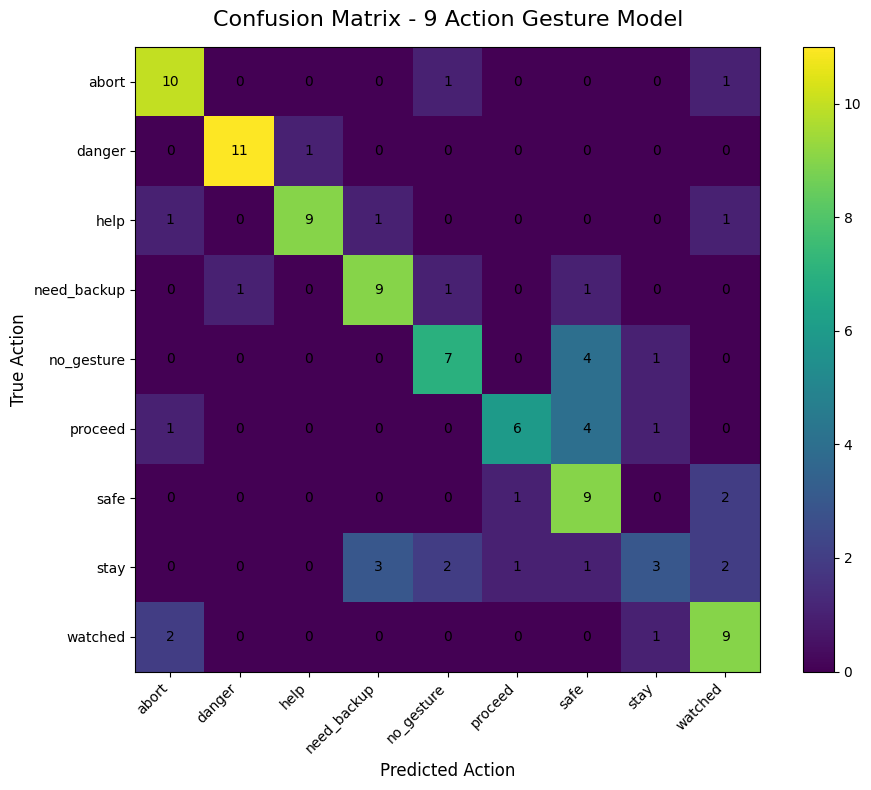

Saved confusion matrix to: /Users/venubandi/Desktop/Gesture_Project/reports/confusion_matrix.png


In [7]:
# ---------------------------------------------------
# CELL 4: Confusion Matrix Heatmap
# ---------------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm)

ax.set_title("Confusion Matrix - 9 Action Gesture Model", fontsize=16, pad=15)
ax.set_xlabel("Predicted Action", fontsize=12)
ax.set_ylabel("True Action", fontsize=12)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=10
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()

cm_path = REPORT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)

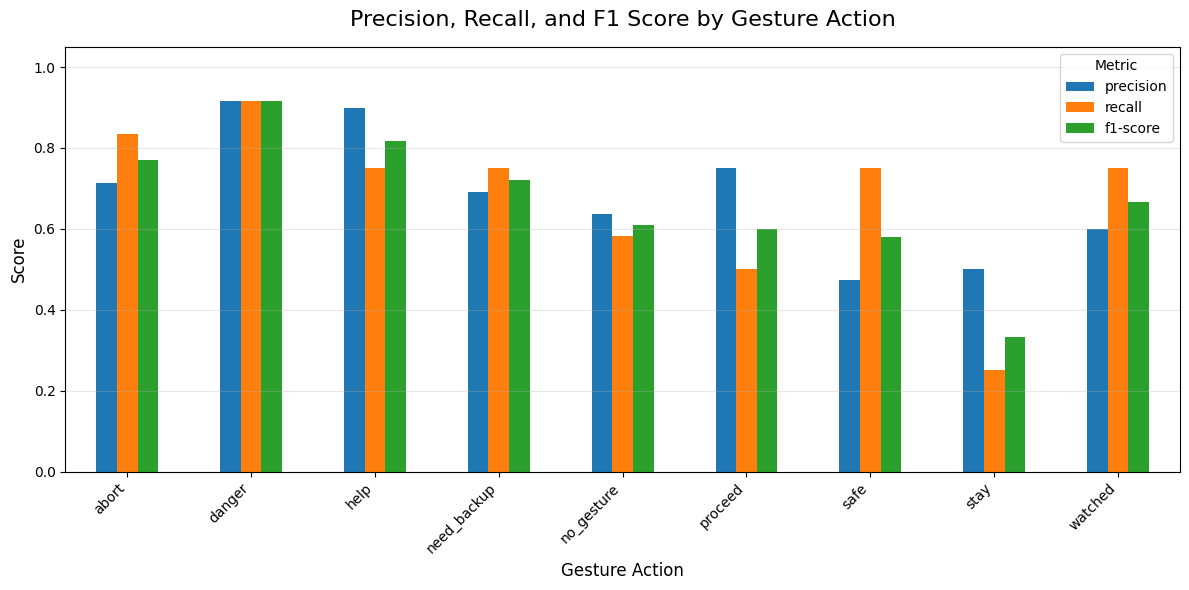

Saved metric comparison chart to: /Users/venubandi/Desktop/Gesture_Project/reports/precision_recall_f1_by_action.png


In [8]:
# ---------------------------------------------------
# CELL 5: Precision, Recall, and F1 by Gesture Action
# ---------------------------------------------------

import matplotlib.pyplot as plt

metrics_df = report_df.loc[class_names, ["precision", "recall", "f1-score"]]

ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Precision, Recall, and F1 Score by Gesture Action", fontsize=16, pad=15)
ax.set_xlabel("Gesture Action", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

metrics_path = REPORT_DIR / "precision_recall_f1_by_action.png"
plt.savefig(metrics_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved metric comparison chart to:", metrics_path)

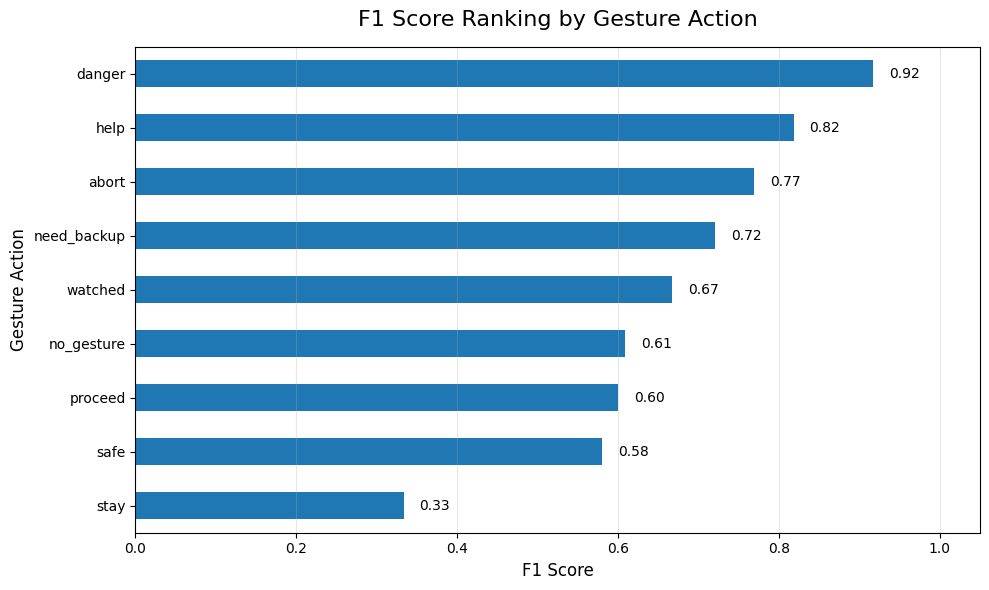

Saved F1 ranking chart to: /Users/venubandi/Desktop/Gesture_Project/reports/f1_score_ranking.png


In [9]:
# ---------------------------------------------------
# CELL 6: F1 Score Ranking by Gesture Action
# ---------------------------------------------------

import matplotlib.pyplot as plt

f1_df = metrics_df[["f1-score"]].sort_values("f1-score", ascending=True)

ax = f1_df.plot(
    kind="barh",
    figsize=(10, 6),
    legend=False
)

ax.set_title("F1 Score Ranking by Gesture Action", fontsize=16, pad=15)
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_ylabel("Gesture Action", fontsize=12)
ax.set_xlim(0, 1.05)
ax.grid(axis="x", alpha=0.3)

for i, value in enumerate(f1_df["f1-score"]):
    ax.text(
        value + 0.02,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

f1_path = REPORT_DIR / "f1_score_ranking.png"
plt.savefig(f1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved F1 ranking chart to:", f1_path)

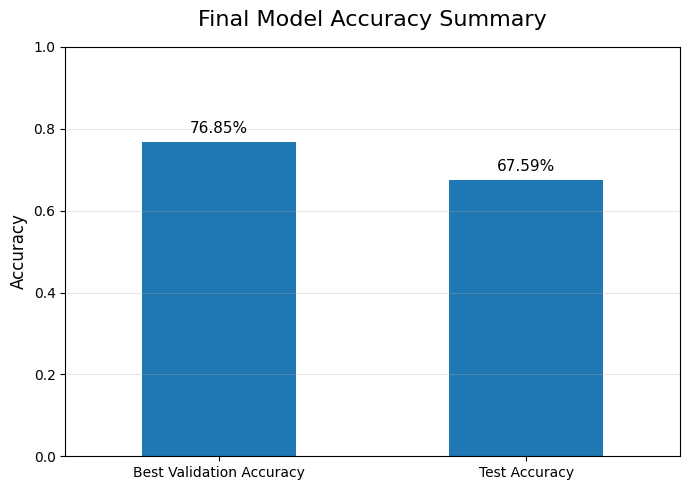

Saved accuracy summary chart to: /Users/venubandi/Desktop/Gesture_Project/reports/validation_test_accuracy_summary.png


,Metric,Accuracy
0,Best Validation Accuracy,0.768519
1,Test Accuracy,0.675926


In [10]:
# ---------------------------------------------------
# CELL 7: Validation vs Test Accuracy Summary
# ---------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd

accuracy_df = pd.DataFrame({
    "Metric": ["Best Validation Accuracy", "Test Accuracy"],
    "Accuracy": [overall_best_val_acc, test_acc]
})

ax = accuracy_df.plot(
    x="Metric",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 5)
)

ax.set_title("Final Model Accuracy Summary", fontsize=16, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(accuracy_df["Accuracy"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center",
        fontsize=11
    )

plt.xticks(rotation=0)
plt.tight_layout()

accuracy_path = REPORT_DIR / "validation_test_accuracy_summary.png"
plt.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved accuracy summary chart to:", accuracy_path)

accuracy_df

In [13]:
# ---------------------------------------------------
# CELL 8: Strong and Weak Action Summary
# ---------------------------------------------------

f1_scores = metrics_df["f1-score"].sort_values(ascending=False)

strong_actions = f1_scores[f1_scores >= 0.70]
weak_actions = f1_scores[f1_scores < 0.70]

print("Strong actions, F1 >= 0.70:")
display(strong_actions.to_frame("F1 Score"))

print("\nWeak / improvement-needed actions, F1 < 0.70:")
display(weak_actions.to_frame("F1 Score"))

summary_df = pd.DataFrame({
    "action": f1_scores.index,
    "f1_score": f1_scores.values,
    "category": [
        "Strong" if score >= 0.70 else "Needs Improvement"
        for score in f1_scores.values
    ]
})

summary_path = REPORT_DIR / "strong_weak_action_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSaved strong/weak summary to:", summary_path)

Strong actions, F1 >= 0.70:


,F1 Score
danger,0.916667
help,0.818182
abort,0.769231
need_backup,0.720000



Weak / improvement-needed actions, F1 < 0.70:


,F1 Score
watched,0.666667
no_gesture,0.608696
proceed,0.600000
safe,0.580645
stay,0.333333



Saved strong/weak summary to: /Users/venubandi/Desktop/Gesture_Project/reports/strong_weak_action_summary.csv


In [14]:
# ---------------------------------------------------
# CELL 9: Presentation-Ready Model Performance Insight
# ---------------------------------------------------

best_action = f1_scores.idxmax()
best_f1 = f1_scores.max()

weakest_action = f1_scores.idxmin()
weakest_f1 = f1_scores.min()

print("MODEL PERFORMANCE SUMMARY")
print("-" * 60)
print(f"Final test accuracy: {test_acc:.2%}")
print(f"Best validation accuracy: {overall_best_val_acc:.2%}")
print(f"Strongest action: {best_action} with F1 score {best_f1:.2f}")
print(f"Weakest action: {weakest_action} with F1 score {weakest_f1:.2f}")
print()
print("Presentation wording:")
print(
    f"""The final 9-action gesture model achieved approximately {test_acc:.1%} test accuracy.
The model performed strongest on actions such as {best_action}, while lower-performing actions such as {weakest_action}
showed more confusion due to overlapping gesture patterns and limited original video samples.
To improve usability in real-time demo conditions, the system includes a dashboard layer, confidence ranking,
event logs, and a rule-based SAFE override using eye-closure duration."""
)

MODEL PERFORMANCE SUMMARY
------------------------------------------------------------
Final test accuracy: 67.59%
Best validation accuracy: 76.85%
Strongest action: danger with F1 score 0.92
Weakest action: stay with F1 score 0.33

Presentation wording:
The final 9-action gesture model achieved approximately 67.6% test accuracy.
The model performed strongest on actions such as danger, while lower-performing actions such as stay
showed more confusion due to overlapping gesture patterns and limited original video samples.
To improve usability in real-time demo conditions, the system includes a dashboard layer, confidence ranking,
event logs, and a rule-based SAFE override using eye-closure duration.


Raw video folder: /Users/venubandi/Desktop/Gesture_Project/dataset/raw_videos
Exists: True
abort: Abort_p01_01.mov | {'face': True, 'pose': True, 'left_hand': False, 'right_hand': True}


I0000 00:00:1779173036.121268 16541859 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1779173036.168017 16577327 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779173036.178501 16577327 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779173036.179594 16577333 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779173036.180057 16577327 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779173036.180511 16577334 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling su

danger: Danger_p01_01.mov | {'face': True, 'pose': True, 'left_hand': True, 'right_hand': False}
help: Help_p01_01.mov | {'face': True, 'pose': True, 'left_hand': True, 'right_hand': False}
need_backup: NeedBackup_p01_01.mov | {'face': True, 'pose': True, 'left_hand': True, 'right_hand': False}
no_gesture: NoGesture_p01_01.mov | {'face': True, 'pose': True, 'left_hand': False, 'right_hand': False}
proceed: Proceed_p01_01.mov | {'face': True, 'pose': True, 'left_hand': False, 'right_hand': False}
safe: Safe_p01_01.mov | {'face': True, 'pose': True, 'left_hand': False, 'right_hand': False}
stay: Stay_p01_01.mov | {'face': True, 'pose': True, 'left_hand': True, 'right_hand': False}
watched: Watched_p01_01.mov | {'face': True, 'pose': True, 'left_hand': False, 'right_hand': True}


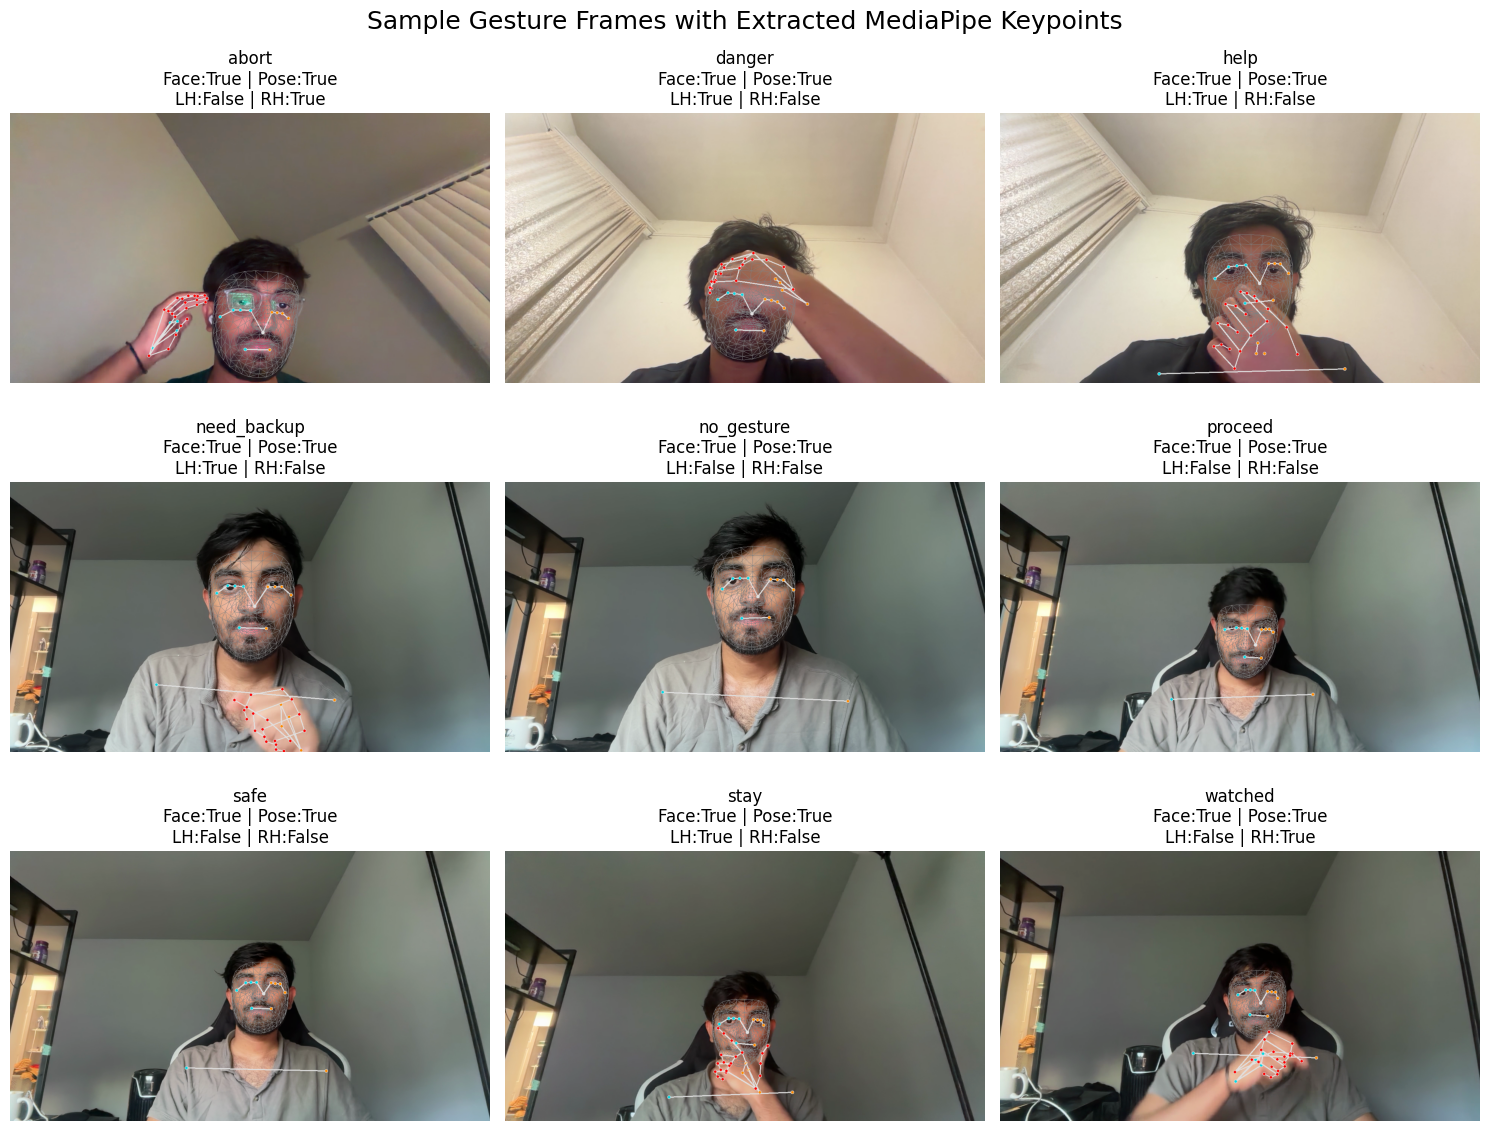

Saved keypoint sample grid to: /Users/venubandi/Desktop/Gesture_Project/reports/sample_gesture_keypoints_grid.png


In [15]:
# ---------------------------------------------------
# CELL: Grid of Sample Action Frames with Extracted Keypoints
# ---------------------------------------------------

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

PROJECT_ROOT = Path.home() / "Desktop" / "Gesture_Project"
RAW_VIDEO_DIR = PROJECT_ROOT / "dataset" / "raw_videos"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Raw video folder:", RAW_VIDEO_DIR)
print("Exists:", RAW_VIDEO_DIR.exists())

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

actions = [
    "abort",
    "danger",
    "help",
    "need_backup",
    "no_gesture",
    "proceed",
    "safe",
    "stay",
    "watched"
]

def get_middle_frame(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    middle_frame_index = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_index)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    return frame

def draw_keypoints_on_frame(frame, holistic):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = holistic.process(frame_rgb)

    annotated = frame.copy()

    # Face mesh
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated,
            landmark_list=results.face_landmarks,
            connections=mp_holistic.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_styles.get_default_face_mesh_tesselation_style()
        )

    # Pose
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated,
            landmark_list=results.pose_landmarks,
            connections=mp_holistic.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style()
        )

    # Left hand
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

    # Right hand
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

    status = {
        "face": results.face_landmarks is not None,
        "pose": results.pose_landmarks is not None,
        "left_hand": results.left_hand_landmarks is not None,
        "right_hand": results.right_hand_landmarks is not None
    }

    return annotated, status

sample_images = []
sample_statuses = []

with mp_holistic.Holistic(
    static_image_mode=True,
    model_complexity=1,
    refine_face_landmarks=True,
    min_detection_confidence=0.5
) as holistic:

    for action in actions:
        action_dir = RAW_VIDEO_DIR / action

        if not action_dir.exists():
            print(f"Missing folder for action: {action}")
            sample_images.append(None)
            sample_statuses.append(None)
            continue

        video_files = sorted(
            list(action_dir.glob("*.mp4")) +
            list(action_dir.glob("*.mov")) +
            list(action_dir.glob("*.avi")) +
            list(action_dir.glob("*.MOV")) +
            list(action_dir.glob("*.MP4"))
        )

        if len(video_files) == 0:
            print(f"No videos found for action: {action}")
            sample_images.append(None)
            sample_statuses.append(None)
            continue

        video_path = video_files[0]
        frame = get_middle_frame(video_path)

        if frame is None:
            print(f"Could not read frame for action: {action}")
            sample_images.append(None)
            sample_statuses.append(None)
            continue

        annotated, status = draw_keypoints_on_frame(frame, holistic)

        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        sample_images.append(annotated_rgb)
        sample_statuses.append(status)

        print(f"{action}: {video_path.name} | {status}")

# ---------------------------------------------------
# Plot grid
# ---------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, action in enumerate(actions):
    ax = axes[i]

    if sample_images[i] is not None:
        ax.imshow(sample_images[i])
        status = sample_statuses[i]

        status_text = (
            f"Face:{status['face']} | Pose:{status['pose']}\n"
            f"LH:{status['left_hand']} | RH:{status['right_hand']}"
        )

        ax.set_title(
            f"{action}\n{status_text}",
            fontsize=12
        )
    else:
        ax.text(
            0.5,
            0.5,
            f"No sample\n{action}",
            ha="center",
            va="center",
            fontsize=14
        )
        ax.set_title(action, fontsize=12)

    ax.axis("off")

plt.suptitle(
    "Sample Gesture Frames with Extracted MediaPipe Keypoints",
    fontsize=18,
    y=0.98
)

plt.tight_layout()

grid_path = REPORT_DIR / "sample_gesture_keypoints_grid.png"
plt.savefig(grid_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved keypoint sample grid to:", grid_path)